In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np 
import onnxruntime as ort
import matplotlib.pyplot as plt
from prepare_images_for_onnx_model import preprocess_for_onnx, decode_image_to_full_scale, reconstruct_image_from_heatmaps

In [2]:
model_path = './cat_centernet.onnx'
session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])


In [3]:
input_name = session.get_inputs()[0].name


In [4]:
image_path = 'dataset/images/frame_04124.png'

In [5]:
network_input = preprocess_for_onnx(image_path)
onnx_outputs = session.run(None, {input_name: network_input})


(40, 56) (40, 56)
807.3177766799927, 201.59397315979004
114.8062973022461, 116.24539947509766
0.45736104249954224, 0.5996233224868774
0.93575317


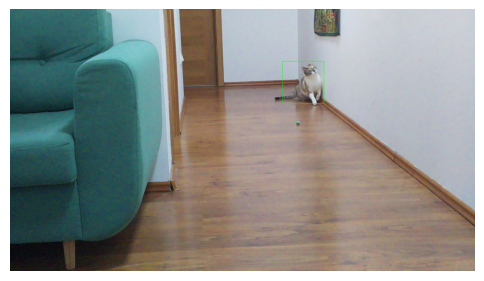

In [6]:
heatmaps = [onnx_outputs[0][0, 0], onnx_outputs[1][0, 0], onnx_outputs[1][0, 1], onnx_outputs[2][0, 0], onnx_outputs[2][0, 1]]
print(heatmaps[0].shape, heatmaps[1].shape)
points, confidence = decode_image_to_full_scale(heatmaps)
image = cv2.imread(image_path)
image = reconstruct_image_from_heatmaps(image, points)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(confidence)
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off') 
plt.show()